# 08B: DIJKSTRA ROUTING (SHARED MODEL APPROACH)

This notebook finds the hottest and coolest pedestrian routes using Dijkstra's algorithm with a raster-only cost surface. The shared model approach uses only the deployment model (raster features) for uniform coverage across the entire study area.

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

MODEL_DIR = Path("models")
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"

print(f"Working directory: {BASE_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [2]:
!pip install osmnx

from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, box

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.4 MB/s eta 0:00:00


## PATH CONFIGURATION

In [3]:
# Input paths.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
NETWORK_FILE = Path("data/processing/network/network.graphml")
DEPLOYMENT_MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
NETWORK_FEATURES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")

# Check if raster already exists from 08a.
PRED_RASTER_ONLY = Path("data/outputs/routing/pred_raster_only.tif")

# Output paths.
OUT_DIR = Path("data/outputs/routing")
OUT_DIR.mkdir(parents = True, exist_ok = True)

COST_SURFACE = OUT_DIR / "cost_surface_shared.tif"
HOTTEST_ROUTE = OUT_DIR / "hottest_route_shared.geojson"

print("PATH CONFIGURATION")
print(f"Boundary file: {BOUNDARY_FILE}")
print(f"Network file: {NETWORK_FILE}")
print(f"Output directory: {OUT_DIR}")

PATH CONFIGURATION
Boundary file: data/inputs/boundaries/aoi_wards.geojson
Network file: data/processing/network/network.graphml
Output directory: data/outputs/routing


## LOAD STUDY AREA BOUNDARIES

In [4]:
# Load ward boundaries.
gdf_wards_original = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards_original)} ward boundaries.")
print(f"Columns: {list(gdf_wards_original.columns)}")
print(f"CRS: {gdf_wards_original.crs}")

# Apply 500m buffer to match network extent.
# First convert to projected CRS for accurate buffering.
print("Applying 500m buffer to ward boundaries...")
gdf_wards_utm = gdf_wards_original.to_crs("EPSG:32648")  # UTM Zone 48N for HCMC.
gdf_wards_buffered = gdf_wards_utm.copy()
gdf_wards_buffered["geometry"] = gdf_wards_buffered.geometry.buffer(500)
gdf_wards = gdf_wards_buffered.to_crs("EPSG:4326")

print(f"Applied 500m buffer to ward boundaries.")
print(f"Buffered wards CRS: {gdf_wards.crs}")
gdf_wards.head()

# Get study area bounds.
total_bounds = gdf_wards.total_bounds
minx, miny, maxx, maxy = total_bounds

print("STUDY AREA BOUNDS (with 500m buffer)")
print(f"Min X (lon): {minx:.6f}")
print(f"Max X (lon): {maxx:.6f}")
print(f"Min Y (lat): {miny:.6f}")
print(f"Max Y (lat): {maxy:.6f}")

Loaded 37 ward boundaries.
Columns: ['OBJECTID', 'COUNTRY', 'ENGNAME', 'NAME_1', 'ENGNAME_1', 'NAME_2', 'ENGNAME_2', 'NAME_3', 'ENGNAME_3', 'TYPE_3', 'ENGTYPE_3', 'Shape_Length', 'Shape_Area', 'geometry']
CRS: EPSG:4326
Applying 500m buffer to ward boundaries...
Applied 500m buffer to ward boundaries.
Buffered wards CRS: EPSG:4326
STUDY AREA BOUNDS (with 500m buffer)
Min X (lon): 106.589987
Max X (lon): 106.814665
Min Y (lat): 10.685335
Max Y (lat): 10.824288


## VISUALIZE STUDY AREA

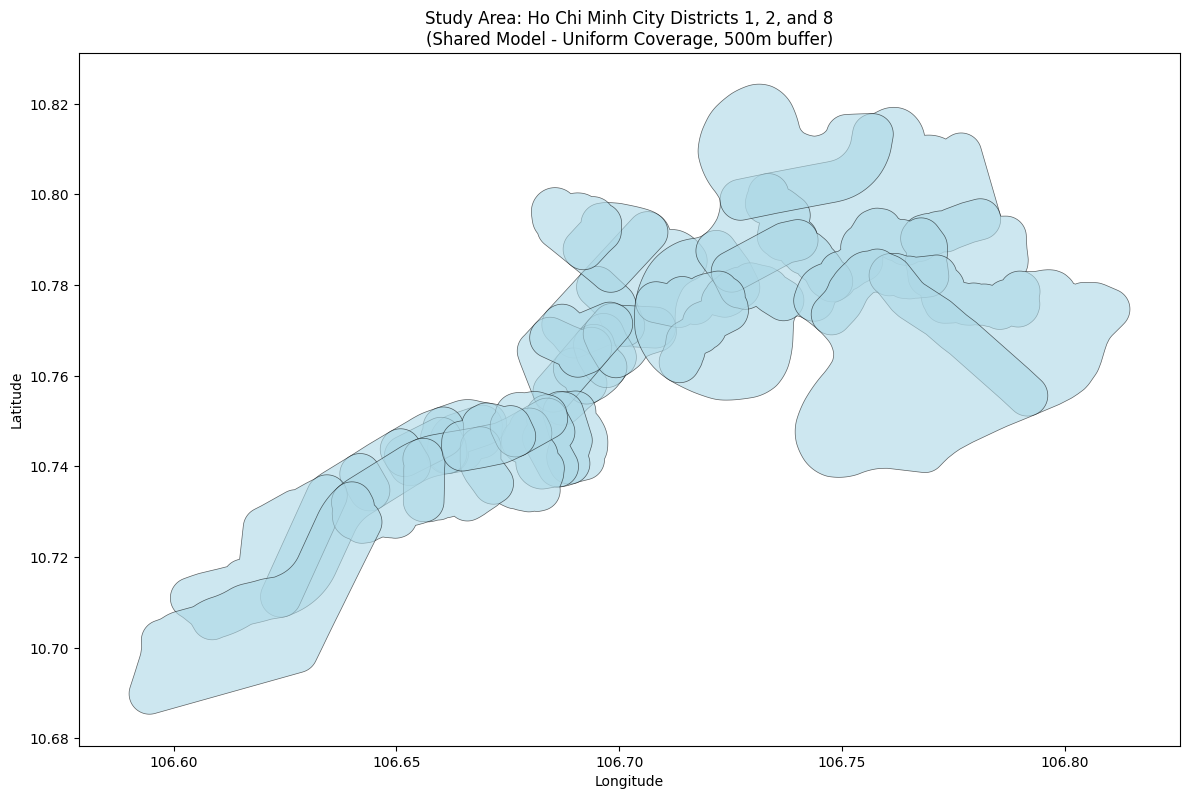

In [5]:
# Create study area visualization.
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Identify district column.
district_col = None
for col in ["district", "District", "quan", "ten_quan"]:
    if col in gdf_wards.columns:
        district_col = col
        break

# Plot wards colored by district.
if district_col:
    gdf_wards.plot(
        ax = ax,
        column = district_col,
        cmap = "Set3",
        edgecolor = "black",
        linewidth = 0.5,
        alpha = 0.6,
        legend = True,
        legend_kwds = {"title": "District", "loc": "upper right"}
    )
else:
    gdf_wards.plot(
        ax = ax,
        facecolor = "lightblue",
        edgecolor = "black",
        linewidth = 0.5,
        alpha = 0.6
    )

# Identify ward column.
ward_col = None
for col in ["ward", "Ward", "name", "NAME", "ten_phuong"]:
    if col in gdf_wards.columns:
        ward_col = col
        break

# Add ward labels.
if ward_col:
    for idx, row in gdf_wards.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            row[ward_col],
            xy = (centroid.x, centroid.y),
            ha = "center",
            fontsize = 5,
            alpha = 0.7
        )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Study Area: Ho Chi Minh City Districts 1, 2, and 8\n(Shared Model - Uniform Coverage, 500m buffer)")

plt.tight_layout()
plt.show()

## LOAD DEPLOYMENT MODEL

In [6]:
# Load deployment model (raster-only features).
with open(DEPLOYMENT_MODEL_FILE, "rb") as f:
    deploy_model_data = pickle.load(f)

model_deploy = deploy_model_data["model"]
features_deploy = deploy_model_data["features"]

print("DEPLOYMENT MODEL (RASTER ONLY)")
print(f"Number of features: {len(features_deploy)}")
print(f"CV R2: {deploy_model_data.get('cv_r2', 'N/A')}")
print(f"CV RMSE: {deploy_model_data.get('cv_rmse', 'N/A')}")
print(f"Features: {features_deploy}")

DEPLOYMENT MODEL (RASTER ONLY)
Number of features: 11
CV R2: 0.4035860965951631
CV RMSE: 1.1569919433047033
Features: ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


## LOAD NETWORK NODE FEATURES

In [7]:
# Load network node features.
df_network = pd.read_csv(NETWORK_FEATURES_FILE)

print(f"Loaded {len(df_network)} network nodes.")
print(f"Columns: {list(df_network.columns)[:15]}")
df_network.head()

Loaded 28445 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## GENERATE RASTER-ONLY PREDICTIONS

In [8]:
# Generate predictions using deployment model.
print("Generating raster-only predictions for entire study area.")

# Extract features for deployment model.
X_deploy = df_network[features_deploy].copy()

# Predict LST using raster-only model.
df_network["pred_lst"] = model_deploy.predict(X_deploy)

print(f"Predictions generated: {len(df_network)} nodes.")
print(f"LST range: min = {df_network['pred_lst'].min():.2f}, max = {df_network['pred_lst'].max():.2f}")
print(f"LST mean: {df_network['pred_lst'].mean():.2f}")
print(f"LST std: {df_network['pred_lst'].std():.2f}")

Generating raster-only predictions for entire study area.
Predictions generated: 28445 nodes.
LST range: min = 37.33, max = 44.04
LST mean: 40.64
LST std: 1.20


## CREATE COST SURFACE RASTER

In [9]:
# Define raster parameters.
RESOLUTION = 0.0001  # Approximately 10 meters at equator.
BUFFER = 0.001  # Small buffer around study area.

# Calculate raster dimensions.
raster_minx = minx - BUFFER
raster_maxx = maxx + BUFFER
raster_miny = miny - BUFFER
raster_maxy = maxy + BUFFER

width = int((raster_maxx - raster_minx) / RESOLUTION)
height = int((raster_maxy - raster_miny) / RESOLUTION)

print("RASTER PARAMETERS")
print(f"Resolution: {RESOLUTION} degrees (~10m)")
print(f"Width: {width} pixels")
print(f"Height: {height} pixels")
print(f"Total pixels: {width * height:,}")

# Create transform.
transform = from_bounds(raster_minx, raster_miny, raster_maxx, raster_maxy, width, height)

# Create coordinate grid.
x_coords = np.linspace(raster_minx, raster_maxx, width)
y_coords = np.linspace(raster_maxy, raster_miny, height)  # Reversed for image coordinates.
xx, yy = np.meshgrid(x_coords, y_coords)

print(f"Grid shape: {xx.shape}")

# Interpolate predictions to grid.
print("Interpolating predictions to raster grid.")

# Get coordinates and values.
points = df_network[["lon", "lat"]].values
values = df_network["pred_lst"].values

# Remove NaN values.
valid_mask = ~np.isnan(values)
points = points[valid_mask]
values = values[valid_mask]

print(f"Valid points for interpolation: {len(points)}")

# Interpolate to grid using linear method.
cost_surface = griddata(
    points,
    values,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

# Fill remaining NaN with nearest neighbor.
nan_mask = np.isnan(cost_surface)
if nan_mask.any():
    print(f"Filling {np.sum(nan_mask)} NaN pixels with nearest neighbor.")
    cost_surface_nearest = griddata(
        points,
        values,
        (xx, yy),
        method = "nearest"
    )
    cost_surface[nan_mask] = cost_surface_nearest[nan_mask]

print(f"Cost surface: min = {np.nanmin(cost_surface):.2f}, max = {np.nanmax(cost_surface):.2f}")

# Save cost surface raster.
print(f"Saving cost surface to {COST_SURFACE}")

with rasterio.open(
    COST_SURFACE,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(cost_surface.astype("float32"), 1)

print("Cost surface raster saved.")

RASTER PARAMETERS
Resolution: 0.0001 degrees (~10m)
Width: 2266 pixels
Height: 1409 pixels
Total pixels: 3,192,794
Grid shape: (1409, 2266)
Interpolating predictions to raster grid.
Valid points for interpolation: 28445
Filling 1849512 NaN pixels with nearest neighbor.
Cost surface: min = 37.38, max = 44.04
Saving cost surface to data/outputs/routing/cost_surface_shared.tif
Cost surface raster saved.


## VISUALIZE COST SURFACE

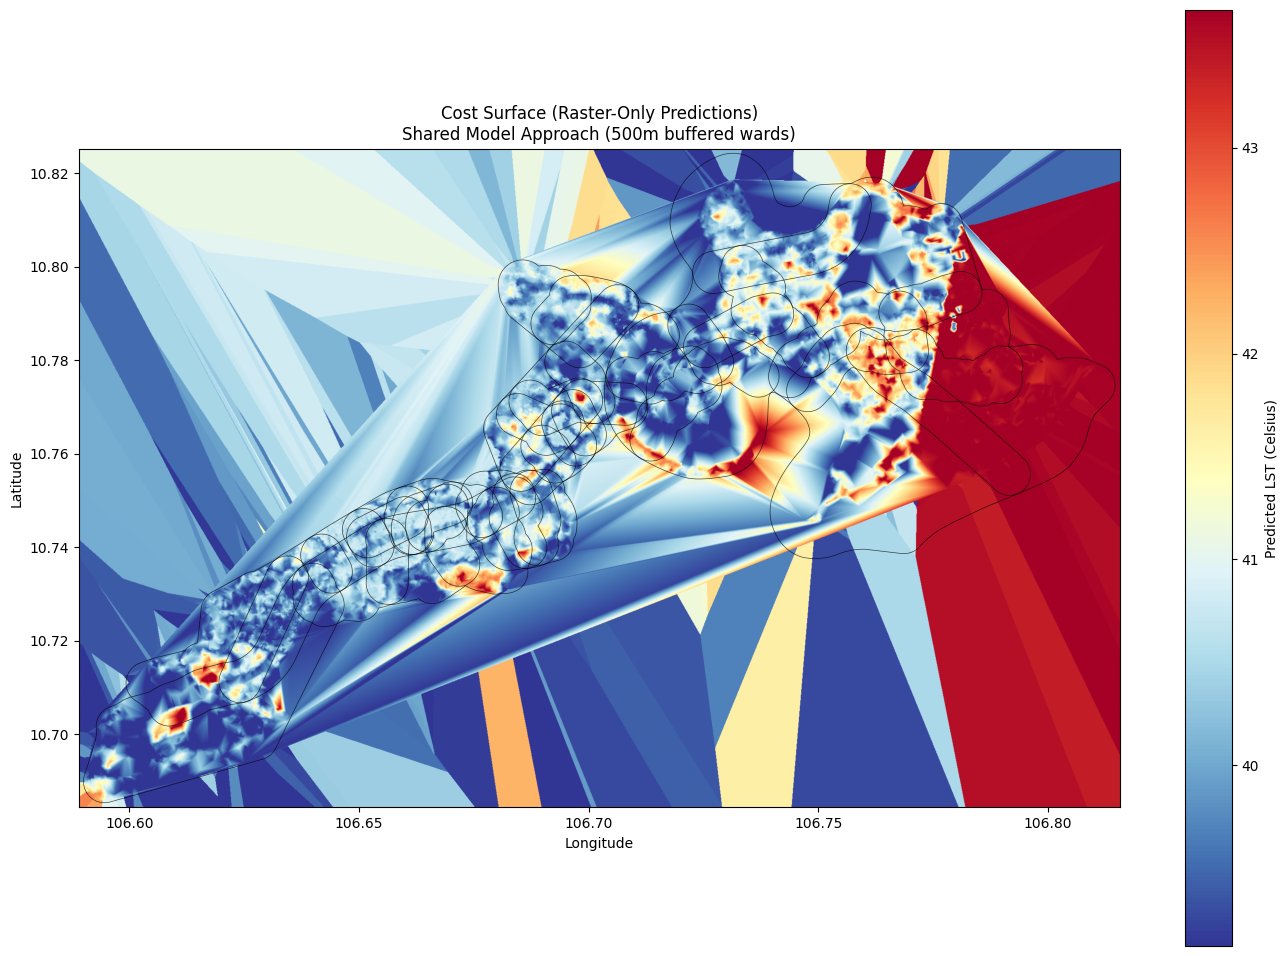

In [10]:
# Visualize cost surface with study area overlay.
fig, ax = plt.subplots(1, 1, figsize = (14, 12))

# Plot cost surface.
im = ax.imshow(
    cost_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(cost_surface, 5),
    vmax = np.nanpercentile(cost_surface, 95),
    origin = "upper"
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "black",
    linewidth = 0.5,
    alpha = 0.7
)

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Cost Surface (Raster-Only Predictions)\nShared Model Approach (500m buffered wards)")

plt.tight_layout()
plt.show()

## LOAD NETWORK GRAPH

In [11]:
# Load network graph.
if NETWORK_FILE.exists():
    G = ox.load_graphml(NETWORK_FILE)
    print(f"Loaded network from file: {len(G.nodes)} nodes, {len(G.edges)} edges.")
else:
    # Download network if not available.
    print("Network file not found. Downloading from OSM.")
    study_area = gdf_wards.unary_union
    G = ox.graph_from_polygon(study_area, network_type = "walk")
    ox.save_graphml(G, NETWORK_FILE)
    print(f"Downloaded network: {len(G.nodes)} nodes, {len(G.edges)} edges.")

# Convert to undirected graph for routing.
G_undirected = G.to_undirected()

print(f"Undirected graph: {len(G_undirected.nodes)} nodes, {len(G_undirected.edges)} edges.")

Loaded network from file: 28445 nodes, 74710 edges.
Undirected graph: 28445 nodes, 37443 edges.


## ASSIGN HEAT WEIGHTS TO EDGES

In [12]:
# Extract node coordinates.
node_coords = {node: (data["x"], data["y"]) for node, data in G_undirected.nodes(data = True)}

print(f"Extracted coordinates for {len(node_coords)} nodes.")

# Compute raster mean once as fallback value for any missing or NaN nodes.
raster_mean = float(np.nanmean(cost_surface))

# Sample LST from cost surface for each node.
print("Sampling LST values from cost surface for each node.")

node_lst = {}

for node, (lon, lat) in node_coords.items():
    # Convert coordinates to pixel indices.
    col = int((lon - raster_minx) / RESOLUTION)
    row = int((raster_maxy - lat) / RESOLUTION)

    # Check bounds.
    if 0 <= row < height and 0 <= col < width:
        lst_value = cost_surface[row, col]
        if not np.isnan(lst_value):
            node_lst[node] = lst_value
        else:
            node_lst[node] = raster_mean
    else:
        node_lst[node] = raster_mean

print(f"Assigned LST values to {len(node_lst)} nodes.")
print(f"LST range: {min(node_lst.values()):.2f} to {max(node_lst.values()):.2f}")

# Assign inverted heat weights to edges.
# Dijkstra finds MINIMUM cost path.
# To find HOTTEST path, invert LST so higher temps have LOWER cost.
print("Assigning inverted heat weights to edges.")

# Get LST range for inversion.
lst_min = min(node_lst.values())
lst_max = max(node_lst.values())

for u, v, data in G_undirected.edges(data = True):
    # Get average LST of edge endpoints.
    lst_u = node_lst.get(u, raster_mean)
    lst_v = node_lst.get(v, raster_mean)
    avg_lst = (lst_u + lst_v) / 2

    # Invert LST: higher temperature = lower cost.
    # Inverted cost = max_LST - actual_LST + small epsilon.
    inverted_cost = lst_max - avg_lst + 0.01

    # Store both original LST and inverted cost.
    data["avg_lst"] = avg_lst
    data["heat_cost"] = inverted_cost

print("Heat weights assigned.")
print(f"Inverted cost range: {lst_max - lst_max + 0.01:.4f} (hottest) to {lst_max - lst_min + 0.01:.4f} (coolest)")

Extracted coordinates for 28445 nodes.
Sampling LST values from cost surface for each node.
Assigned LST values to 28445 nodes.
LST range: 37.41 to 44.02
Assigning inverted heat weights to edges.
Heat weights assigned.
Inverted cost range: 0.0100 (hottest) to 6.6206 (coolest)


## SELECT START AND END POINTS

In [13]:
# Select start and end points far apart for interesting route.
# Use opposite corners of study area for maximum distance.
print("Selecting start and end points.")

# Find nodes near southwest and northeast corners.
sw_corner = (minx + 0.005, miny + 0.005)
ne_corner = (maxx - 0.005, maxy - 0.005)

# Find nearest nodes to corners.
start_node = ox.nearest_nodes(G_undirected, sw_corner[0], sw_corner[1])
end_node = ox.nearest_nodes(G_undirected, ne_corner[0], ne_corner[1])

start_coords = node_coords[start_node]
end_coords = node_coords[end_node]

print(f"Start node: {start_node} at ({start_coords[0]:.6f}, {start_coords[1]:.6f})")
print(f"End node: {end_node} at ({end_coords[0]:.6f}, {end_coords[1]:.6f})")

# Calculate straight-line distance.
from math import radians, sin, cos, sqrt, atan2

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters.
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1) * cos(phi2) * sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

distance = haversine(start_coords[0], start_coords[1], end_coords[0], end_coords[1])
print(f"Straight-line distance: {distance:.0f} meters ({distance/1000:.2f} km)")

Selecting start and end points.
Start node: 3074863945 at (106.594831, 10.690103)
End node: 2635150551 at (106.781346, 10.809230)
Straight-line distance: 24303 meters (24.30 km)


## RUN DIJKSTRA FOR HOTTEST PATH

In [14]:
# Run Dijkstra algorithm with inverted heat cost.
print("Running Dijkstra algorithm to find HOTTEST path.")

try:
    hottest_path = nx.dijkstra_path(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    hottest_path_length = nx.dijkstra_path_length(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    print(f"Hottest path found: {len(hottest_path)} nodes.")
    print(f"Total inverted cost: {hottest_path_length:.2f}")

except nx.NetworkXNoPath:
    print("No path found between start and end nodes.")
    hottest_path = None

# Calculate path statistics.
if hottest_path:
    path_lsts = []
    path_coords = []

    for node in hottest_path:
        path_lsts.append(node_lst.get(node, np.nan))
        path_coords.append(node_coords[node])

    print("HOTTEST PATH STATISTICS")
    print(f"Number of nodes: {len(hottest_path)}")
    print(f"Average LST along path: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST along path: {np.nanmax(path_lsts):.2f} C")
    print(f"Min LST along path: {np.nanmin(path_lsts):.2f} C")
    print(f"LST std along path: {np.nanstd(path_lsts):.2f} C")

    # Calculate path length in meters.
    total_distance = 0
    for i in range(len(path_coords) - 1):
        lon1, lat1 = path_coords[i]
        lon2, lat2 = path_coords[i + 1]
        total_distance += haversine(lon1, lat1, lon2, lat2)

    print(f"Total path length: {total_distance:.0f} meters ({total_distance/1000:.2f} km)")

Running Dijkstra algorithm to find HOTTEST path.
Hottest path found: 300 nodes.
Total inverted cost: 1053.84
HOTTEST PATH STATISTICS
Number of nodes: 300
Average LST along path: 40.50 C
Max LST along path: 43.92 C
Min LST along path: 38.38 C
LST std along path: 1.08 C
Total path length: 35482 meters (35.48 km)


## COMPARE WITH SHORTEST PATH

In [15]:
# Find shortest path for comparison.
print("Finding shortest path for comparison.")

try:
    shortest_path = nx.dijkstra_path(
        G_undirected,
        start_node,
        end_node,
        weight = "length"
    )

    # Calculate shortest path LST statistics.
    shortest_lsts = [node_lst.get(n, np.nan) for n in shortest_path]
    shortest_coords = [node_coords[n] for n in shortest_path]

    # Calculate shortest path length.
    shortest_distance = 0
    for i in range(len(shortest_coords) - 1):
        lon1, lat1 = shortest_coords[i]
        lon2, lat2 = shortest_coords[i + 1]
        shortest_distance += haversine(lon1, lat1, lon2, lat2)

    print("SHORTEST PATH STATISTICS")
    print(f"Number of nodes: {len(shortest_path)}")
    print(f"Average LST along path: {np.nanmean(shortest_lsts):.2f} C")
    print(f"Max LST along path: {np.nanmax(shortest_lsts):.2f} C")
    print(f"Path length: {shortest_distance:.0f} meters ({shortest_distance/1000:.2f} km)")

    print("")
    print("COMPARISON")
    print(f"Hottest path avg LST: {np.nanmean(path_lsts):.2f} C")
    print(f"Shortest path avg LST: {np.nanmean(shortest_lsts):.2f} C")
    print(f"LST difference: {np.nanmean(path_lsts) - np.nanmean(shortest_lsts):.2f} C")
    print(f"Distance difference: {total_distance - shortest_distance:.0f} meters")

except nx.NetworkXNoPath:
    print("No shortest path found.")
    shortest_path = None

Finding shortest path for comparison.
SHORTEST PATH STATISTICS
Number of nodes: 509
Average LST along path: 40.36 C
Max LST along path: 43.95 C
Path length: 28180 meters (28.18 km)

COMPARISON
Hottest path avg LST: 40.50 C
Shortest path avg LST: 40.36 C
LST difference: 0.14 C
Distance difference: 7302 meters


## VISUALIZE HOTTEST ROUTE

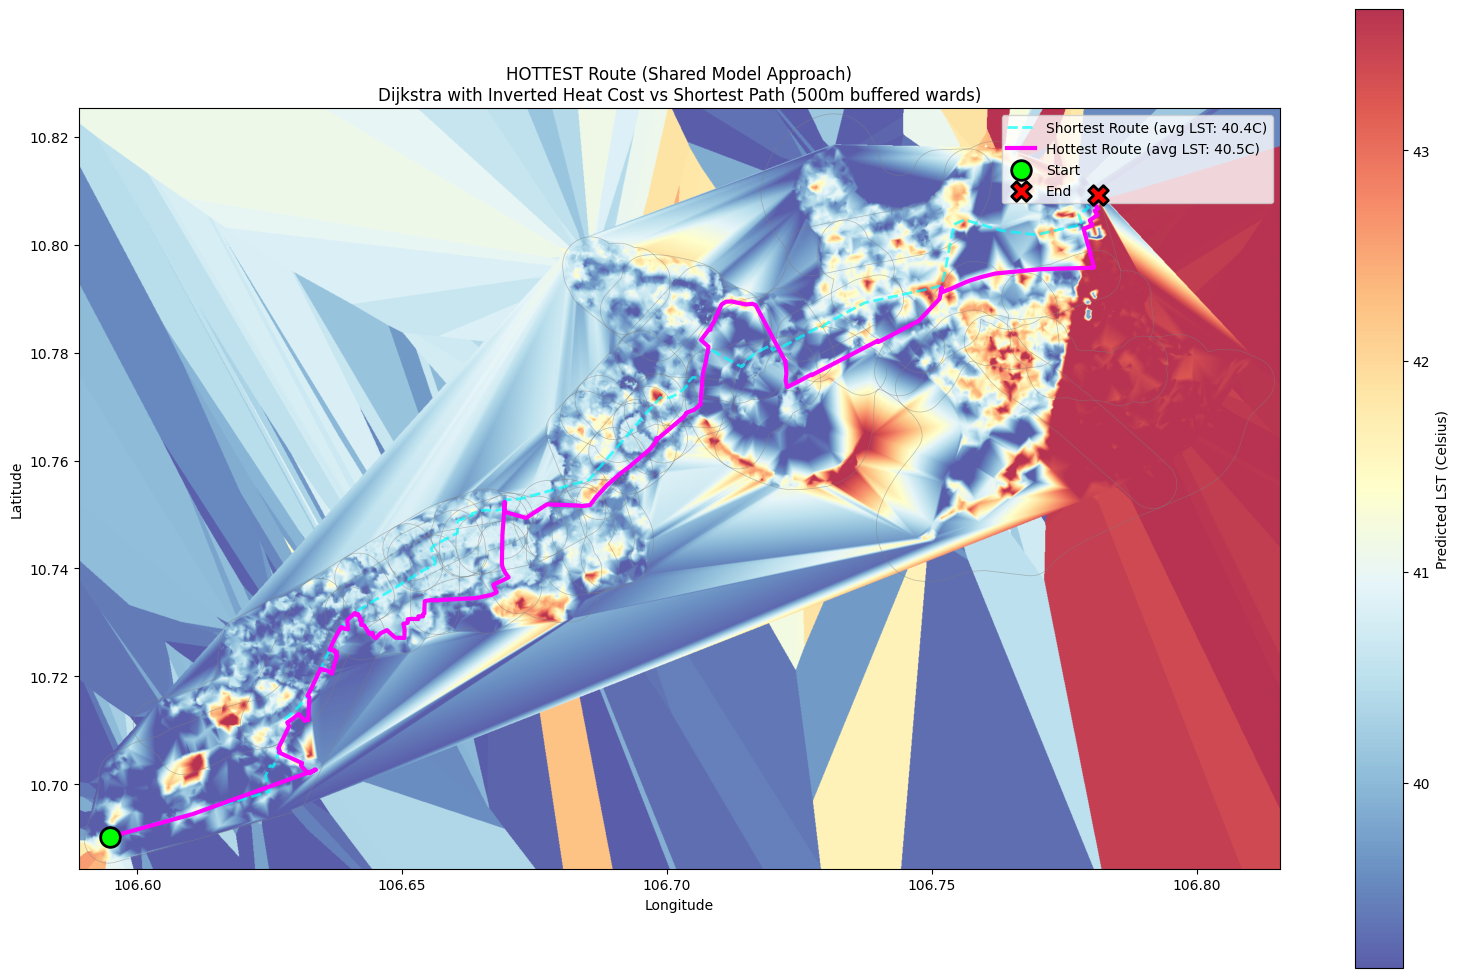

In [16]:
# Create visualization of hottest route over cost surface.
fig, ax = plt.subplots(1, 1, figsize = (16, 14))

# Plot cost surface.
im = ax.imshow(
    cost_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(cost_surface, 5),
    vmax = np.nanpercentile(cost_surface, 95),
    origin = "upper",
    alpha = 0.8
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "gray",
    linewidth = 0.5,
    alpha = 0.5
)

# Plot shortest path for comparison.
if shortest_path:
    short_x = [node_coords[n][0] for n in shortest_path]
    short_y = [node_coords[n][1] for n in shortest_path]

    ax.plot(
        short_x,
        short_y,
        color = "cyan",
        linewidth = 2,
        linestyle = "--",
        label = f"Shortest Route (avg LST: {np.nanmean(shortest_lsts):.1f}C)",
        zorder = 9,
        alpha = 0.7
    )

# Plot hottest path.
if hottest_path:
    path_x = [node_coords[n][0] for n in hottest_path]
    path_y = [node_coords[n][1] for n in hottest_path]

    ax.plot(
        path_x,
        path_y,
        color = "magenta",
        linewidth = 3,
        label = f"Hottest Route (avg LST: {np.nanmean(path_lsts):.1f}C)",
        zorder = 10
    )

    # Mark start and end.
    ax.scatter(
        [start_coords[0]],
        [start_coords[1]],
        c = "lime",
        s = 200,
        marker = "o",
        edgecolor = "black",
        linewidth = 2,
        label = "Start",
        zorder = 11
    )

    ax.scatter(
        [end_coords[0]],
        [end_coords[1]],
        c = "red",
        s = 200,
        marker = "X",
        edgecolor = "black",
        linewidth = 2,
        label = "End",
        zorder = 11
    )

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("HOTTEST Route (Shared Model Approach)\nDijkstra with Inverted Heat Cost vs Shortest Path (500m buffered wards)")
ax.legend(loc = "upper right")

plt.tight_layout()
plt.show()

## SAVE HOTTEST ROUTE

In [17]:
# Save hottest route as GeoJSON.
if hottest_path:
    # Create LineString geometry.
    route_line = LineString(path_coords)

    # Create GeoDataFrame.
    gdf_route = gpd.GeoDataFrame(
        {
            "route_type": ["hottest_shared"],
            "num_nodes": [len(hottest_path)],
            "avg_lst": [np.nanmean(path_lsts)],
            "max_lst": [np.nanmax(path_lsts)],
            "min_lst": [np.nanmin(path_lsts)],
            "length_m": [total_distance],
        },
        geometry = [route_line],
        crs = "EPSG:4326"
    )

    # Save to file.
    gdf_route.to_file(HOTTEST_ROUTE, driver = "GeoJSON")

    print(f"Hottest route saved to {HOTTEST_ROUTE}")
    print(gdf_route)

Hottest route saved to data/outputs/routing/hottest_route_shared.geojson
       route_type  num_nodes    avg_lst    max_lst   min_lst      length_m  \
0  hottest_shared        300  40.501022  43.915607  38.37795  35481.823042   

                                            geometry  
0  LINESTRING (106.59483 10.6901, 106.59546 10.69...  


## LST PROFILE ALONG PATH

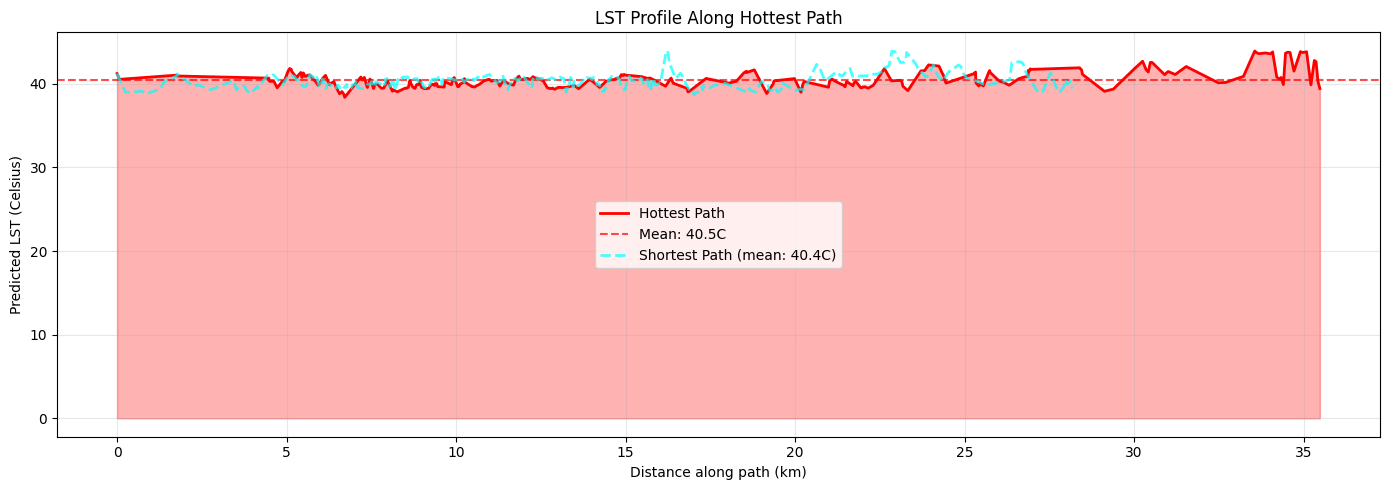

In [18]:
# Plot LST profile along hottest path.
if hottest_path:
    fig, ax = plt.subplots(1, 1, figsize = (14, 5))

    # Calculate cumulative distance along path.
    cumulative_dist = [0]
    for i in range(len(path_coords) - 1):
        lon1, lat1 = path_coords[i]
        lon2, lat2 = path_coords[i + 1]
        segment_dist = haversine(lon1, lat1, lon2, lat2)
        cumulative_dist.append(cumulative_dist[-1] + segment_dist)

    # Convert to kilometers.
    cumulative_dist_km = [d / 1000 for d in cumulative_dist]

    # Plot LST profile.
    ax.fill_between(
        cumulative_dist_km,
        path_lsts,
        alpha = 0.3,
        color = "red"
    )
    ax.plot(
        cumulative_dist_km,
        path_lsts,
        color = "red",
        linewidth = 2,
        label = "Hottest Path"
    )

    # Add mean line.
    ax.axhline(
        np.nanmean(path_lsts),
        color = "red",
        linestyle = "--",
        alpha = 0.7,
        label = f"Mean: {np.nanmean(path_lsts):.1f}C"
    )

    # Plot shortest path LST if available.
    if shortest_path:
        short_cumulative = [0]
        for i in range(len(shortest_coords) - 1):
            lon1, lat1 = shortest_coords[i]
            lon2, lat2 = shortest_coords[i + 1]
            segment_dist = haversine(lon1, lat1, lon2, lat2)
            short_cumulative.append(short_cumulative[-1] + segment_dist)

        short_cumulative_km = [d / 1000 for d in short_cumulative]

        ax.plot(
            short_cumulative_km,
            shortest_lsts,
            color = "cyan",
            linewidth = 2,
            linestyle = "--",
            alpha = 0.7,
            label = f"Shortest Path (mean: {np.nanmean(shortest_lsts):.1f}C)"
        )

    ax.set_xlabel("Distance along path (km)")
    ax.set_ylabel("Predicted LST (Celsius)")
    ax.set_title("LST Profile Along Hottest Path")
    ax.legend()
    ax.grid(alpha = 0.3)

    plt.tight_layout()
    plt.show()

## SUMMARY

In [19]:
print("SHARED MODEL DIJKSTRA SUMMARY")
print("")
print("Approach: Use raster-only predictions for uniform coverage across study area.")
print("Note: 500m buffer applied to ward boundaries to match network extent.")
print("")
print("OUTPUTS")
print(f"Cost surface: {COST_SURFACE}")
print(f"Hottest route: {HOTTEST_ROUTE}")
print("")
if hottest_path:
    print("HOTTEST ROUTE STATISTICS")
    print(f"Path length: {total_distance/1000:.2f} km")
    print(f"Average LST: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST: {np.nanmax(path_lsts):.2f} C")
    print(f"Min LST: {np.nanmin(path_lsts):.2f} C")
    print("")
    if shortest_path:
        print("COMPARISON WITH SHORTEST PATH")
        print(f"Shortest path avg LST: {np.nanmean(shortest_lsts):.2f} C")
        print(f"LST gain by taking hottest: +{np.nanmean(path_lsts) - np.nanmean(shortest_lsts):.2f} C")
        print(f"Distance penalty: +{(total_distance - shortest_distance)/1000:.2f} km")

SHARED MODEL DIJKSTRA SUMMARY

Approach: Use raster-only predictions for uniform coverage across study area.
Note: 500m buffer applied to ward boundaries to match network extent.

OUTPUTS
Cost surface: data/outputs/routing/cost_surface_shared.tif
Hottest route: data/outputs/routing/hottest_route_shared.geojson

HOTTEST ROUTE STATISTICS
Path length: 35.48 km
Average LST: 40.50 C
Max LST: 43.92 C
Min LST: 38.38 C

COMPARISON WITH SHORTEST PATH
Shortest path avg LST: 40.36 C
LST gain by taking hottest: +0.14 C
Distance penalty: +7.30 km


## MULTI-OD-PAIR EVALUATION

The single-route demo above only shows one OD pair, which cannot establish whether temperature differences are systematic or route-specific. This section samples 13 OD pairs across three distance classes (5 short, 5 medium, 3 long) and runs shortest/coolest/hottest routing on each to measure the distribution of temperature differences.

**Distance classes:**
- Short: 1-3 km straight-line (neighborhood trips).
- Medium: 3-8 km straight-line (cross-district trips).
- Long: 10+ km straight-line (full study area traversals).

In [20]:
import os
from math import radians, sin, cos, sqrt, atan2

def haversine_dist(lon1, lat1, lon2, lat2):
    """
    Compute great-circle distance in meters between two lon/lat points.
    """
    R = 6371000  # Earth radius in meters.
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlambda / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

def compute_route_stats(G, path, node_lst_dict, node_coords_dict):
    """
    Compute distance (via haversine) and average LST for a route path.
    Returns (distance_m, avg_lst, max_lst).
    """
    temps = [node_lst_dict.get(n, np.nan) for n in path]
    coords = [node_coords_dict[n] for n in path]

    dist_m = 0.0
    for i in range(len(coords) - 1):
        dist_m += haversine_dist(coords[i][0], coords[i][1], coords[i + 1][0], coords[i + 1][1])

    return dist_m, np.nanmean(temps), np.nanmax(temps)

In [21]:
# Sample OD pairs at different distance classes.
# Strategy: randomly sample node pairs, bin by straight-line distance,
# keep the first N that fall in each class.
import random

random.seed(42)
np.random.seed(42)

all_nodes = list(G_undirected.nodes)

# Target counts per distance class.
targets = {
    "short": {"min_km": 1.0, "max_km": 3.0, "n": 5, "pairs": []},
    "medium": {"min_km": 3.0, "max_km": 8.0, "n": 5, "pairs": []},
    "long": {"min_km": 10.0, "max_km": 50.0, "n": 3, "pairs": []},
}

# Sample candidate pairs until all bins are filled.
max_attempts = 50000
attempts = 0

while attempts < max_attempts:
    n1, n2 = random.sample(all_nodes, 2)
    c1 = node_coords[n1]
    c2 = node_coords[n2]
    d_km = haversine_dist(c1[0], c1[1], c2[0], c2[1]) / 1000.0

    for cls_name, cls_info in targets.items():
        if len(cls_info["pairs"]) < cls_info["n"]:
            if cls_info["min_km"] <= d_km <= cls_info["max_km"]:
                cls_info["pairs"].append((n1, n2, d_km))
                break

    # Check if all bins are full.
    if all(len(t["pairs"]) >= t["n"] for t in targets.values()):
        break

    attempts += 1

print("SAMPLED OD PAIRS")
for cls_name, cls_info in targets.items():
    print(f"  {cls_name}: {len(cls_info['pairs'])} pairs (target: {cls_info['n']})")

SAMPLED OD PAIRS
  short: 5 pairs (target: 5)
  medium: 5 pairs (target: 5)
  long: 3 pairs (target: 3)


In [22]:
# Run routing for all OD pairs.
od_results = []

for cls_name, cls_info in targets.items():
    for pair_idx, (origin, destination, straight_km) in enumerate(cls_info["pairs"]):
        pair_label = f"{cls_name}_{pair_idx + 1}"

        # Shortest route.
        try:
            sp = nx.dijkstra_path(G_undirected, origin, destination, weight = "length")
            sp_dist, sp_avg, sp_max = compute_route_stats(G_undirected, sp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            continue

        # Coolest route.
        try:
            cp = nx.dijkstra_path(G_undirected, origin, destination, weight = "cool_cost")
            cp_dist, cp_avg, cp_max = compute_route_stats(G_undirected, cp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            cp_dist, cp_avg, cp_max = np.nan, np.nan, np.nan

        # Hottest route.
        try:
            hp = nx.dijkstra_path(G_undirected, origin, destination, weight = "hot_cost")
            hp_dist, hp_avg, hp_max = compute_route_stats(G_undirected, hp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            hp_dist, hp_avg, hp_max = np.nan, np.nan, np.nan

        od_results.append({
            "pair": pair_label,
            "class": cls_name,
            "straight_km": round(straight_km, 2),
            "shortest_dist_m": round(sp_dist, 0),
            "shortest_avg_lst": round(sp_avg, 2),
            "coolest_dist_m": round(cp_dist, 0),
            "coolest_avg_lst": round(cp_avg, 2),
            "hottest_dist_m": round(hp_dist, 0),
            "hottest_avg_lst": round(hp_avg, 2),
            "cool_vs_short_lst": round(sp_avg - cp_avg, 2),
            "cool_vs_short_dist_pct": round((cp_dist - sp_dist) / sp_dist * 100, 1),
            "hot_vs_cool_lst": round(hp_avg - cp_avg, 2),
        })

df_od = pd.DataFrame(od_results)

print("MULTI-OD ROUTING RESULTS")
print(df_od.to_string(index = False))

MULTI-OD ROUTING RESULTS
    pair  class  straight_km  shortest_dist_m  shortest_avg_lst  coolest_dist_m  coolest_avg_lst  hottest_dist_m  hottest_avg_lst  cool_vs_short_lst  cool_vs_short_dist_pct  hot_vs_cool_lst
 short_1  short         2.51           3273.0             39.67          3687.0            39.74          3687.0            39.74              -0.06                    12.7              0.0
 short_2  short         2.03           2887.0             40.88          3377.0            40.91          3377.0            40.91              -0.03                    17.0              0.0
 short_3  short         2.05           2208.0             40.52          2491.0            40.33          2491.0            40.33               0.20                    12.8              0.0
 short_4  short         1.45           1939.0             40.45          2350.0            40.57          2350.0            40.57              -0.13                    21.2              0.0
 short_5  short         2

In [23]:
# Summary statistics across all OD pairs.
print("SUMMARY STATISTICS ACROSS ALL OD PAIRS")
print(f"Total valid pairs: {len(df_od)}")
print("")

# Coolest vs shortest LST difference.
cool_diff = df_od["cool_vs_short_lst"]
print("Coolest route LST reduction vs shortest (C):")
print(f"  Mean: {cool_diff.mean():.3f}")
print(f"  Median: {cool_diff.median():.3f}")
print(f"  Min: {cool_diff.min():.3f}")
print(f"  Max: {cool_diff.max():.3f}")
print(f"  Std: {cool_diff.std():.3f}")
print("")

# Distance penalty for coolest route.
dist_penalty = df_od["cool_vs_short_dist_pct"]
print("Distance penalty for coolest route vs shortest (%):")
print(f"  Mean: {dist_penalty.mean():.1f}%")
print(f"  Median: {dist_penalty.median():.1f}%")
print(f"  Range: [{dist_penalty.min():.1f}%, {dist_penalty.max():.1f}%]")
print("")

# Hottest vs coolest spread.
hot_cool = df_od["hot_vs_cool_lst"]
print("Hottest vs coolest route LST spread (C):")
print(f"  Mean: {hot_cool.mean():.3f}")
print(f"  Median: {hot_cool.median():.3f}")
print(f"  Max: {hot_cool.max():.3f}")
print("")

# By distance class.
print("BY DISTANCE CLASS")
for cls_name in ["short", "medium", "long"]:
    subset = df_od[df_od["class"] == cls_name]
    if len(subset) > 0:
        print(f"  {cls_name} (n={len(subset)}): cool reduction = {subset['cool_vs_short_lst'].mean():.3f} C, dist penalty = {subset['cool_vs_short_dist_pct'].mean():.1f}%, hot-cool spread = {subset['hot_vs_cool_lst'].mean():.3f} C")

SUMMARY STATISTICS ACROSS ALL OD PAIRS
Total valid pairs: 13

Coolest route LST reduction vs shortest (C):
  Mean: 0.079
  Median: 0.080
  Min: -0.210
  Max: 0.340
  Std: 0.163

Distance penalty for coolest route vs shortest (%):
  Mean: 13.9%
  Median: 12.8%
  Range: [3.1%, 28.7%]

Hottest vs coolest route LST spread (C):
  Mean: 0.000
  Median: 0.000
  Max: 0.000

BY DISTANCE CLASS
  short (n=5): cool reduction = 0.022 C, dist penalty = 16.2%, hot-cool spread = 0.000 C
  medium (n=5): cool reduction = 0.068 C, dist penalty = 15.7%, hot-cool spread = 0.000 C
  long (n=3): cool reduction = 0.193 C, dist penalty = 7.2%, hot-cool spread = 0.000 C


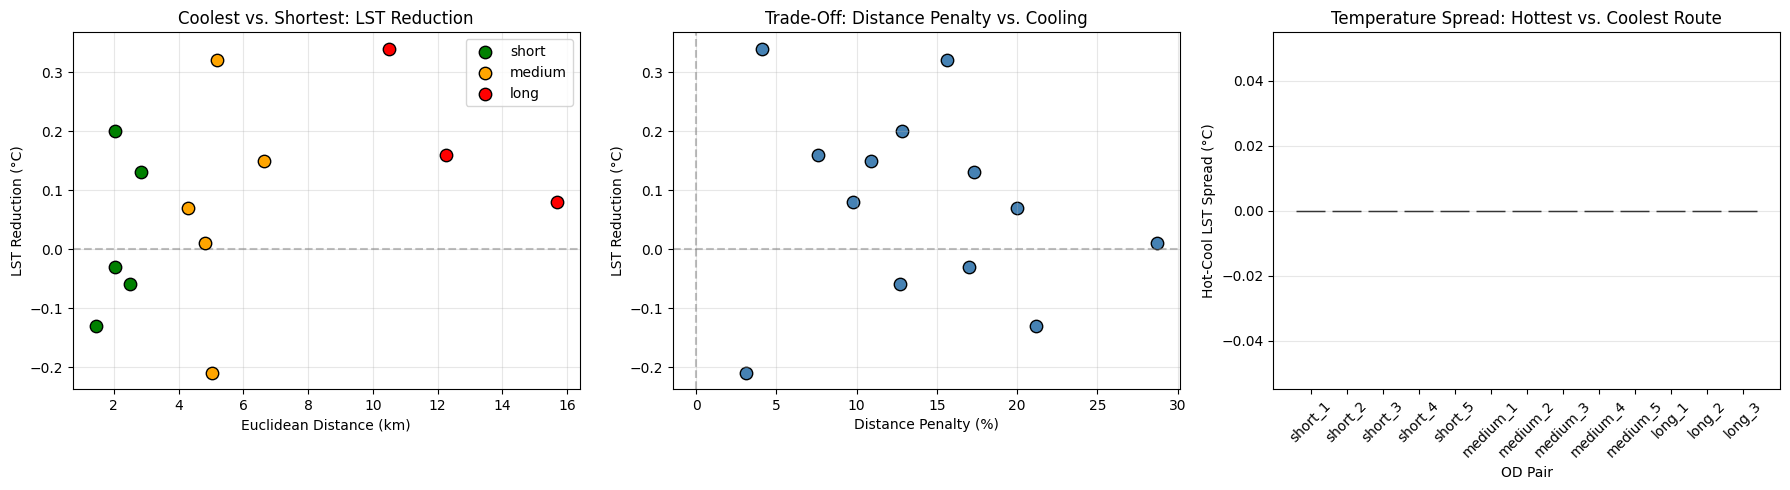

In [24]:
# Visualization of multi-OD results.
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Panel 1: LST reduction (coolest vs shortest) by distance class.
for cls_name, color in [("short", "green"), ("medium", "orange"), ("long", "red")]:
    subset = df_od[df_od["class"] == cls_name]
    axes[0].scatter(subset["straight_km"], subset["cool_vs_short_lst"], c = color, s = 80, label = cls_name, edgecolor = "black", zorder = 5)

axes[0].axhline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[0].set_xlabel("Euclidean Distance (km)")
axes[0].set_ylabel("LST Reduction (°C)")
axes[0].set_title("Coolest vs. Shortest: LST Reduction")
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Panel 2: Distance penalty vs LST reduction.
axes[1].scatter(df_od["cool_vs_short_dist_pct"], df_od["cool_vs_short_lst"], c = "steelblue", s = 80, edgecolor = "black")
axes[1].set_xlabel("Distance Penalty (%)")
axes[1].set_ylabel("LST Reduction (°C)")
axes[1].set_title("Trade-Off: Distance Penalty vs. Cooling")
axes[1].axhline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[1].axvline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[1].grid(alpha = 0.3)

# Panel 3: Hot-cool spread.
axes[2].bar(df_od["pair"], df_od["hot_vs_cool_lst"], color = "coral", edgecolor = "black")
axes[2].set_xlabel("OD Pair")
axes[2].set_ylabel("Hot-Cool LST Spread (°C)")
axes[2].set_title("Temperature Spread: Hottest vs. Coolest Route")
axes[2].tick_params(axis = "x", rotation = 45)
axes[2].grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "route_comparison_shared_model.png", dpi = 300, bbox_inches = "tight")
plt.show()